# **Backtest Assignment**

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [57]:
import os
import sys

import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

import warnings
warnings.filterwarnings('ignore')

from typing import Tuple, Dict, Any, List
from pathlib import Path
from IPython.display import display

from datetime import datetime, timedelta, time
import time

from tqdm.notebook import tqdm

src_path = os.path.abspath('../src')
sys.path.append(src_path)

from prepare_data import load_and_process_data
from exchange_v2 import ExchangeSim, OpportunisticSpreadWidenMM, SWRParams, run_backtest, BTLogger

pd.options.display.float_format = '{:.6f}'.format
pd.set_option('display.max_columns', None)

In [4]:
# Symbol name
asset_name= 'HYPEUSDT'
quotes_df, trades_df, events_df = load_and_process_data(asset_name)

In [5]:
quotes_df.head()

,ts,exchange,symbol,timestamp,local_timestamp,asks[0].price,asks[0].amount,bids[0].price,bids[0].amount,asks[1].price,asks[1].amount,bids[1].price,bids[1].amount,asks[2].price,asks[2].amount,bids[2].price,bids[2].amount,asks[3].price,asks[3].amount,bids[3].price,bids[3].amount,asks[4].price,asks[4].amount,bids[4].price,bids[4].amount,asks[5].price,asks[5].amount,bids[5].price,bids[5].amount,asks[6].price,asks[6].amount,bids[6].price,bids[6].amount,asks[7].price,asks[7].amount,bids[7].price,bids[7].amount,asks[8].price,asks[8].amount,bids[8].price,bids[8].amount,asks[9].price,asks[9].amount,bids[9].price,bids[9].amount,asks[10].price,asks[10].amount,bids[10].price,bids[10].amount,asks[11].price,asks[11].amount,bids[11].price,bids[11].amount,asks[12].price,asks[12].amount,bids[12].price,bids[12].amount,asks[13].price,asks[13].amount,bids[13].price,bids[13].amount,asks[14].price,asks[14].amount,bids[14].price,bids[14].amount,asks[15].price,asks[15].amount,bids[15].price,bids[15].amount,asks[16].price,asks[16].amount,bids[16].price,bids[16].amount,asks[17].price,asks[17].amount,bids[17].price,bids[17].amount,asks[18].price,asks[18].amount,bids[18].price,bids[18].amount,asks[19].price,asks[19].amount,bids[19].price,bids[19].amount,asks[20].price,asks[20].amount,bids[20].price,bids[20].amount,asks[21].price,asks[21].amount,bids[21].price,bids[21].amount,asks[22].price,asks[22].amount,bids[22].price,bids[22].amount,asks[23].price,asks[23].amount,bids[23].price,bids[23].amount,asks[24].price,asks[24].amount,bids[24].price,bids[24].amount,ts_us,date,best_ask,best_bid,mid,spread,spread_bps,spread_med_bps
0,2025-08-01 00:00:00.149,binance-futures,HYPEUSDT,1754006400149000,1754006401048006,40.824000,10.000000,40.823000,13.170000,40.827000,0.380000,40.822000,5.370000,40.830000,5.230000,40.821000,6.330000,40.832000,7.820000,40.820000,80.230000,40.833000,24.180000,40.819000,12.310000,40.834000,31.380000,40.818000,16.740000,40.835000,28.590000,40.817000,14.840000,40.836000,136.710000,40.816000,35.190000,40.837000,27.880000,40.815000,70.830000,40.838000,138.450000,40.814000,14.970000,40.840000,376.190000,40.813000,18.520000,40.841000,0.540000,40.812000,29.410000,40.842000,144.110000,40.811000,6.740000,40.844000,11822.840000,40.810000,57.810000,40.845000,1.420000,40.809000,6.330000,40.846000,52.910000,40.808000,0.630000,40.847000,80.840000,40.807000,0.560000,40.848000,130.080000,40.806000,2.580000,40.849000,2.990000,40.805000,111.230000,40.850000,188.470000,40.804000,703.620000,40.851000,208.490000,40.803000,375.790000,40.852000,144.250000,40.802000,75.280000,40.853000,15.750000,40.801000,15.330000,40.854000,86.610000,40.800000,75.080000,40.855000,39.370000,40.799000,38.360000,1754006400149000,2025-08-01,40.824000,40.823000,40.823500,0.001000,0.244957,0.244957
1,2025-08-01 00:00:01.777,binance-futures,HYPEUSDT,1754006401777000,1754006401780745,40.829000,0.130000,40.826000,10.100000,40.832000,2.590000,40.825000,1.870000,40.833000,24.180000,40.823000,53.970000,40.834000,5.370000,40.822000,5.370000,40.835000,2.580000,40.821000,6.330000,40.836000,39.100000,40.820000,77.570000,40.837000,27.880000,40.819000,12.310000,40.838000,92.220000,40.818000,6.950000,40.840000,331.410000,40.817000,14.840000,40.841000,0.540000,40.816000,35.190000,40.842000,70.790000,40.815000,70.830000,40.844000,11773.410000,40.814000,14.970000,40.845000,1.420000,40.813000,18.520000,40.846000,173.170000,40.812000,29.410000,40.847000,80.840000,40.811000,6.740000,40.848000,130.080000,40.810000,57.810000,40.849000,3.270000,40.809000,6.330000,40.850000,192.610000,40.808000,0.630000,40.851000,209.180000,40.807000,0.560000,40.852000,148.540000,40.806000,28.760000,40.853000,15.750000,40.805000,111.230000,40.854000,15.260000,40.804000,703.620000,40.855000,39.370000,40.803000,375.790000,40.856000,125.100000,40.802000,75.280000,40.857000,644.230000,40.801000,15.330000,1754006401777000,2025-08-01,40.829000,40.826000,40.827500,0.003000,0.734799,0.734799
2,2025-08-01 00:00:01.830,binance-futu

In [6]:
print("n_quotes:", len(quotes_df), "n_trades:", len(trades_df), "n_events:", len(events_df))
print("event types:\n", events_df["etype"].value_counts())

# monotonic time
assert events_df["ts_us"].is_monotonic_increasing

# check any identical timestamps (normal in crypto feeds)
same_ts = (events_df["ts_us"].diff() == 0).sum()
print("same-timestamp transitions:", int(same_ts))

n_quotes: 1333853 n_trades: 1686533 n_events: 3020386
event types:
 etype
trade    1686533
quote    1333853
Name: count, dtype: int64
same-timestamp transitions: 1258584


## Running the skeleton

In [13]:
sim = ExchangeSim(
    asset_name='HYPE',
    tick_size=0.001,
    maker_fee=0.0002,
    taker_fee=0.0005,
    latency_us=5_000,      # start with 5ms; tune later
    depth_levels=5,
)

# Example: place one passive buy at best_bid, then run
# We'll place after first quote arrives (so book is valid)

placed = False
for ev in events_df.itertuples(index=False):
    if ev.etype == "quote":
        row = quotes_df.iloc[ev.qidx]
        sim.on_quote(row)
        if (not placed) and sim.book.is_valid():
            oid = sim.place_limit("buy", sim.book.snap.best_bid, qty=0.01, ts_us=ev.ts_us)
            placed = True

    else:  # trade
        trow = trades_df.iloc[ev.tidx]
        sim.on_trade(trow, ts_us=ev.ts_us)

# Inspect
print("pos:", sim.pos, "cash:", sim.cash, "n_fills:", len(sim.fills), "active:", len(sim.active_ids))
pd.DataFrame([f.__dict__ for f in sim.fills]).head()

pos: 0.01 cash: -0.40831164600000003 n_fills: 1 active: 0


,ts_us,order_id,side,price,qty,fee
0,1754006402199000,1,buy,40.823000,0.010000,0.000082


## **Run the backtest**

In [25]:
params = SWRParams()

sim = ExchangeSim(
    asset_name="HYPE",
    tick_size=0.001,
    maker_fee=0.0002,
    taker_fee=0.0005,
    latency_us=5_000,
    depth_levels=5,
)

strategy = OpportunisticSpreadWidenMM(params)

eq = run_backtest(events_df, quotes_df, trades_df, sim, strategy)

fills_df = pd.DataFrame([f.__dict__ for f in sim.fills])
print("fills:", len(fills_df), "final pos:", sim.pos, "final cash:", sim.cash)
fills_df

fills: 26 final pos: 8.969999999999999 final cash: -383.600407174


,ts_us,order_id,side,price,qty,fee
0,1754006462416000,1,buy,40.881000,0.130000,0.001063
1,1754006462416000,1,buy,40.881000,0.130000,0.001063
2,1754006462416000,1,buy,40.881000,2.740000,0.022403
3,1754007113595000,3,buy,40.670000,2.460000,0.020010
4,1754007113595000,3,buy,40.670000,0.540000,0.004392
5,1754007121224000,5,buy,40.641000,3.000000,0.024385
6,1754009518761000,9,buy,40.427000,3.000000,0.024256
7,1754009839353000,11,buy,40.873000,3.000000,0.024524
8,1754010591843000,15,sell,40.978000,0.130000,0.001065
9,1754010591856000,15,sell,40.978000,2.440000,0.019997


In [20]:
# all orders ever created
orders_df = pd.DataFrame(
    {oid: vars(o) for oid, o in sim.orders.items()}
).T

orders_df[["order_id", "side", "price", "qty", "is_active", "is_done"]]

,order_id,side,price,qty,is_active,is_done
1,1,buy,40.881000,3.000000,False,True
2,2,sell,40.887000,3.000000,False,True
3,3,buy,40.670000,3.000000,False,True
4,4,sell,40.676000,3.000000,False,True
5,5,buy,40.641000,3.000000,False,True
...,...,...,...,...,...,...
79,79,sell,36.890000,3.000000,False,True
80,80,buy,36.820000,3.000000,False,True
81,81,sell,36.827000,3.000000,False,True
82,82,buy,36.974000,3.000000,False,True


## **Run backtest with Logger**

In [92]:
# After implementing log
params = SWRParams()

sim = ExchangeSim(
    asset_name="HYPE",
    tick_size=0.001,
    maker_fee=0.0002,
    taker_fee=0.0005,
    latency_us=5_000,
    depth_levels=5,
)

logger = BTLogger()

strategy = OpportunisticSpreadWidenMM(params, logger=logger)
eq = run_backtest(events_df, quotes_df, trades_df, sim, strategy, logger)

log_df = logger.to_df()

In [87]:
log_df.head()

,ts_us,event_i,etype,action,reason,spread_bps,med_bps,pos,enter_thr_bps,enter_excess_bps,side,order_id,price,qty,fill_source,fee,cash,elapsed_ms,tox_count,tox_total,tox_net,best_bid,best_ask,gated_side,Q_max,old_price,new_price,ts
0,1754006462405000,4187,quote,REGIME,enter_regime,1.956756,0.244565,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-01 00:01:02.405000+00:00
1,1754006462405000,4187,quote,REGIME,enter_regime,1.956756,0.244565,NaN,1.711952,0.244804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-01 00:01:02.405000+00:00
2,1754006462405000,4187,quote,PLACE,enter_regime,NaN,NaN,0.000000,NaN,NaN,buy,1.000000,40.881000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-01 00:01:02.405000+00:00
3,1754006462405000,4187,quote,PLACE,enter_regime,NaN,NaN,0.000000,NaN,NaN,sell,2.000000,40.887000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-01 00:01:02.405000+00:00
4,1754006462416000,4188,trade,FILL,NaN,NaN,NaN,0.130000,NaN,NaN,buy,1.000000,40.881000,0.130000,trade_through,0.001063,-5.315593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-01 00:01:02.416000+00:00


In [93]:
log_df["reason"].value_counts()

reason
tox_fail                    7550
exit_suppressed_min_hold    2611
enter_regime                1400
exit_regime                 1329
inv_gate                      81
tight_spread                  68
price_change                  36
ttl                           10
Name: count, dtype: int64

In [94]:
log_df["action"].value_counts()

action
CANCEL_ALL    7606
REGIME        5229
PLACE          114
GATE            81
CANCEL          55
FILL            44
Name: count, dtype: int64

In [84]:
display(log_df.query("action == 'FILL'")["fill_source"].value_counts())

fill_source
trade_through    26
quote_cross      18
Name: count, dtype: int64

In [85]:
display(log_df.query("action == 'PLACE'")[["ts","side","order_id","reason","price","qty"]].head())

,ts,side,order_id,reason,price,qty
2,2025-08-01 00:01:02.405000+00:00,buy,1.000000,enter_regime,40.881000,3.000000
3,2025-08-01 00:01:02.405000+00:00,sell,2.000000,enter_regime,40.887000,3.000000
150,2025-08-01 00:11:53.582000+00:00,buy,3.000000,enter_regime,40.670000,3.000000
151,2025-08-01 00:11:53.582000+00:00,sell,4.000000,enter_regime,40.676000,3.000000
165,2025-08-01 00:12:01.146000+00:00,buy,5.000000,enter_regime,40.641000,3.000000


In [86]:
display(log_df.query("action == 'CANCEL'")[["ts","side","order_id","reason"]].head())

,ts,side,order_id,reason
10,2025-08-01 00:01:02.456000+00:00,buy,1.000000,tox_fail
11,2025-08-01 00:01:02.456000+00:00,sell,2.000000,tox_fail
157,2025-08-01 00:11:53.633000+00:00,buy,3.000000,tox_fail
158,2025-08-01 00:11:53.633000+00:00,sell,4.000000,tox_fail
569,2025-08-01 00:46:03.535000+00:00,buy,7.000000,tox_fail


In [62]:
# fills_df = pd.DataFrame([f.__dict__ for f in sim.fills])
# print("fills:", len(fills_df), "final pos:", sim.pos, "final cash:", sim.cash)
# fills_df.head()

In [49]:
# all orders ever created
orders_df = pd.DataFrame(
    {oid: vars(o) for oid, o in sim.orders.items()}
).T

n_orders = orders_df.shape[0]
n_filled_orders = fills_df["order_id"].nunique()

fill_rate = n_filled_orders / n_orders
print("Fill rate:", fill_rate)

Fill rate: 0.23931623931623933


In [50]:
fills_df = fills_df.sort_values("ts_us")

fills_df["signed_qty"] = np.where(
    fills_df["side"] == "buy",
    fills_df["qty"],
    -fills_df["qty"]
)

fills_df["signed_notional"] = np.where(
    fills_df["side"] == "buy",
    -fills_df["price"] * fills_df["qty"],
    fills_df["price"] * fills_df["qty"]
)

fills_df["pnl_contrib"] = fills_df["signed_notional"] - fills_df["fee"]
fills_df["cum_pnl"] = fills_df["pnl_contrib"].cumsum()
win_rate = (fills_df["pnl_contrib"] > 0).mean()
win_rate

np.float64(0.34782608695652173)

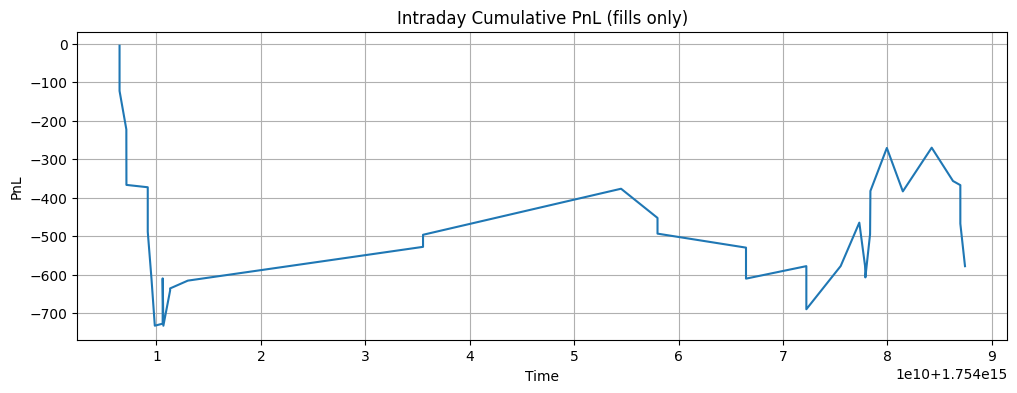

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(fills_df["ts_us"], fills_df["cum_pnl"])
plt.title("Intraday Cumulative PnL (fills only)")
plt.xlabel("Time")
plt.ylabel("PnL")
plt.grid(True)
plt.show()

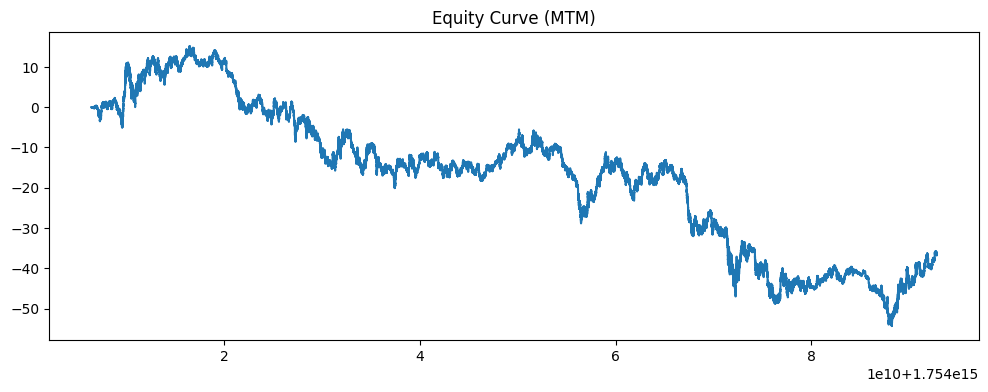

In [52]:
plt.figure(figsize=(12,4))
plt.plot(eq["ts_us"], eq["equity"])
plt.title("Equity Curve (MTM)")
plt.show()

In [53]:
log_df.groupby("action")["event_i"].count() / len(events_df)

action
CANCEL       0.000019
CANCEL_ALL   0.001294
FILL         0.000015
GATE         0.000027
PLACE        0.000039
REGIME       0.001763
Name: event_i, dtype: float64

# **Log Analysis**

**Step 1 — Build an “episode table” (each regime window)**

We want to group everything between enter_regime and exit_regime into episodes so we can see what happened per opportunity.

What to look for:

- Are episodes super short (like tens of ms)? → regime threshold chatter
- Are many episodes long but we don’t place? → toxicity filter too strict / tight spread

In [95]:
ld = log_df.copy().sort_values(["ts_us","event_i"]).reset_index(drop=True)

# mark regime flips
reg = ld[(ld.action=="REGIME") & (ld.reason.isin(["enter_regime","exit_regime"]))][
    ["ts_us","event_i","reason","spread_bps","med_bps","pos"]
].copy()

# pair enter->exit
enters = reg[reg.reason=="enter_regime"].reset_index(drop=True)
exits  = reg[reg.reason=="exit_regime"].reset_index(drop=True)

# if counts mismatch (end of day), align by index min len
m = min(len(enters), len(exits))
episodes = pd.DataFrame({
    "enter_ts_us": enters.loc[:m-1, "ts_us"].values,
    "enter_event_i": enters.loc[:m-1, "event_i"].values,
    "enter_spread_bps": enters.loc[:m-1, "spread_bps"].values,
    "enter_med_bps": enters.loc[:m-1, "med_bps"].values,
    "enter_pos": enters.loc[:m-1, "pos"].values,
    "exit_ts_us": exits.loc[:m-1, "ts_us"].values,
    "exit_event_i": exits.loc[:m-1, "event_i"].values,
})

episodes["dur_ms"] = (episodes["exit_ts_us"] - episodes["enter_ts_us"]) / 1000.0
#episodes.describe()

In [99]:
display(log_df["action"].value_counts())
display(log_df[log_df.action=="REGIME"]["reason"].value_counts())

action
CANCEL_ALL    7606
REGIME        5229
PLACE          114
GATE            81
CANCEL          55
FILL            44
Name: count, dtype: int64

reason
exit_suppressed_min_hold    2611
enter_regime                1309
exit_regime                 1309
Name: count, dtype: int64

In [100]:
reg = log_df[(log_df.action=="REGIME")][["ts_us","reason","event_i"]].copy()
reg["delta_ms"] = reg["ts_us"].diff() / 1000
display(reg.head(30))

,ts_us,reason,event_i,delta_ms
0,1754006462405000,enter_regime,4187,NaN
6,1754006462456000,exit_suppressed_min_hold,4199,51.000000
11,1754006462509000,exit_suppressed_min_hold,4200,53.000000
14,1754006462561000,exit_regime,4201,52.000000
15,1754006546214000,enter_regime,7967,83653.000000
18,1754006546265000,exit_suppressed_min_hold,7997,51.000000
21,1754006546316000,exit_suppressed_min_hold,7998,51.000000
24,1754006546368000,exit_regime,7999,52.000000
25,1754006646733000,enter_regime,10455,100365.000000
28,1754006646786000,exit_suppressed_min_hold,10456,53.000000


In [101]:
reg2 = log_df[(log_df.action=="REGIME") & (log_df.reason.isin(["enter_regime","exit_regime"]))] \
        .sort_values(["ts_us","event_i"])

episodes = []
open_enter = None
for r in reg2.itertuples(index=False):
    if r.reason == "enter_regime":
        if open_enter is None:
            open_enter = r
    else:
        if open_enter is not None:
            episodes.append({
                "enter_ts_us": open_enter.ts_us,
                "exit_ts_us": r.ts_us,
                "dur_ms": (r.ts_us - open_enter.ts_us)/1000,
                "enter_event_i": open_enter.event_i,
                "exit_event_i": r.event_i,
            })
            open_enter = None
episodes = pd.DataFrame(episodes)

display(episodes["dur_ms"].describe())
display((episodes["dur_ms"] <= 300).mean())   # optional quick view

count   1309.000000
mean     156.742552
std        5.055974
min      152.000000
25%      154.000000
50%      155.000000
75%      158.000000
max      222.000000
Name: dur_ms, dtype: float64

np.float64(1.0)

In [102]:
tox = log_df.query("action=='CANCEL_ALL' and reason=='tox_fail'")
tox[["tox_count","tox_total","tox_net"]].describe()

,tox_count,tox_total,tox_net
count,3769.000000,3769.000000,3769.000000
mean,54.826479,714.261648,-220.996983
std,92.210303,2090.321591,2059.643581
min,1.000000,5.230000,-36518.590000
25%,19.000000,81.760000,-203.270000
50%,30.000000,201.670000,-32.660000
75%,52.000000,519.930000,136.050000
max,1345.000000,39642.850000,13815.150000


In [90]:
reg = log_df[log_df.action=="REGIME"][["ts_us","reason","event_i"]].copy()
reg["delta_ms"] = reg["ts_us"].diff() / 1000
reg.head(20)

,ts_us,reason,event_i,delta_ms
0,1754006462405000,enter_regime,4187,NaN
1,1754006462405000,enter_regime,4187,0.000000
7,1754006462456000,exit_suppressed_min_hold,4199,51.000000
12,1754006462509000,exit_suppressed_min_hold,4200,53.000000
15,1754006462561000,exit_regime,4201,52.000000
16,1754006546214000,enter_regime,7967,83653.000000
17,1754006546214000,enter_regime,7967,0.000000
20,1754006546265000,exit_suppressed_min_hold,7997,51.000000
23,1754006546316000,exit_suppressed_min_hold,7998,51.000000
26,1754006546368000,exit_regime,7999,52.000000


In [91]:
reg = log_df[log_df.action=="REGIME"][["ts_us","reason","event_i"]].copy()
reg["delta_ms"] = reg["ts_us"].diff() / 1000
reg.head(20)

,ts_us,reason,event_i,delta_ms
0,1754006462405000,enter_regime,4187,NaN
1,1754006462405000,enter_regime,4187,0.000000
7,1754006462456000,exit_suppressed_min_hold,4199,51.000000
12,1754006462509000,exit_suppressed_min_hold,4200,53.000000
15,1754006462561000,exit_regime,4201,52.000000
16,1754006546214000,enter_regime,7967,83653.000000
17,1754006546214000,enter_regime,7967,0.000000
20,1754006546265000,exit_suppressed_min_hold,7997,51.000000
23,1754006546316000,exit_suppressed_min_hold,7998,51.000000
26,1754006546368000,exit_regime,7999,52.000000


In [55]:
log_df.query("reason == 'exit_suppressed_min_hold'")["elapsed_ms"].describe()

count   2659.000000
mean      78.271531
std       26.251002
min       51.000000
25%       51.000000
50%      102.000000
75%      103.000000
max      139.000000
Name: elapsed_ms, dtype: float64

In [59]:
# Randomly pick cases to see the pattern
enter_idx = log_df.index[log_df.reason=="enter_regime"].to_numpy()
sample = np.random.choice(enter_idx, size=20, replace=False)

for idx in sample:
    print("----")
    display(log_df.loc[idx, ["ts","event_i","spread_bps","med_bps","pos"]])
    display(log_df.iloc[idx:idx+10][["ts","event_i","etype","action","reason","pos"]])

----


ts            2025-08-01 20:05:33.675000+00:00
event_i                                2513196
spread_bps                            2.675943
med_bps                               0.267641
pos                                   9.070000
Name: 7944, dtype: object

,ts,event_i,etype,action,reason,pos
7944,2025-08-01 20:05:33.675000+00:00,2513196,quote,REGIME,enter_regime,9.070000
7945,2025-08-01 20:05:33.675000+00:00,2513196,quote,CANCEL_ALL,tox_fail,9.070000
7946,2025-08-01 20:05:33.728000+00:00,2513197,quote,REGIME,exit_suppressed_min_hold,9.070000
7947,2025-08-01 20:05:33.728000+00:00,2513197,quote,CANCEL_ALL,tox_fail,9.070000
7948,2025-08-01 20:05:33.779000+00:00,2513198,quote,REGIME,exit_suppressed_min_hold,9.070000
7949,2025-08-01 20:05:33.779000+00:00,2513198,quote,CANCEL_ALL,tox_fail,9.070000
7950,2025-08-01 20:05:33.831000+00:00,2513199,quote,REGIME,exit_regime,9.070000
7951,2025-08-01 20:05:35.589000+00:00,2513260,quote,REGIME,enter_regime,9.070000
7952,2025-08-01 20:05:35.589000+00:00,2513260,quote,CANCEL_ALL,tox_fail,9.070000
7953,2025-08-01 20:05:35.640000+00:00,2513261,quote,REGIME,exit_suppressed_min_hold,9.070000


----


ts            2025-08-01 22:23:08.570000+00:00
event_i                                2802247
spread_bps                            2.983010
med_bps                               0.271102
pos                                  11.400000
Name: 8680, dtype: object

...

ts            2025-08-01 03:21:32.063000+00:00
event_i                                 391175
spread_bps                            1.929524
med_bps                               0.241217
pos                                  15.140000
Name: 1488, dtype: object

,ts,event_i,etype,action,reason,pos
1488,2025-08-01 03:21:32.063000+00:00,391175,quote,REGIME,enter_regime,15.140000
1489,2025-08-01 03:21:32.063000+00:00,391175,quote,CANCEL_ALL,tox_fail,15.140000
1490,2025-08-01 03:21:32.115000+00:00,391180,quote,REGIME,exit_suppressed_min_hold,15.140000
1491,2025-08-01 03:21:32.115000+00:00,391180,quote,CANCEL_ALL,tox_fail,15.140000
1492,2025-08-01 03:21:32.166000+00:00,391181,quote,REGIME,exit_suppressed_min_hold,15.140000
1493,2025-08-01 03:21:32.166000+00:00,391181,quote,CANCEL_ALL,tox_fail,15.140000
1494,2025-08-01 03:21:32.218000+00:00,391182,quote,REGIME,exit_regime,15.140000
1495,2025-08-01 03:34:59.138000+00:00,408371,quote,REGIME,enter_regime,15.140000
1496,2025-08-01 03:34:59.138000+00:00,408371,quote,CANCEL_ALL,tox_fail,15.140000
1497,2025-08-01 03:34:59.189000+00:00,408372,quote,REGIME,exit_suppressed_min_hold,15.140000


----


ts            2025-08-01 23:10:44.122000+00:00
event_i                                2932726
spread_bps                            2.420624
med_bps                               0.268994
pos                                  14.400000
Name: 9394, dtype: object

,ts,event_i,etype,action,reason,pos
9394,2025-08-01 23:10:44.122000+00:00,2932726,quote,REGIME,enter_regime,14.400000
9395,2025-08-01 23:10:44.122000+00:00,2932726,quote,CANCEL_ALL,tox_fail,14.400000
9396,2025-08-01 23:10:44.173000+00:00,2932732,quote,REGIME,exit_suppressed_min_hold,14.400000
9397,2025-08-01 23:10:44.173000+00:00,2932732,quote,CANCEL_ALL,tox_fail,14.400000
9398,2025-08-01 23:10:44.225000+00:00,2932734,quote,REGIME,exit_suppressed_min_hold,14.400000
9399,2025-08-01 23:10:44.225000+00:00,2932734,quote,CANCEL_ALL,tox_fail,14.400000
9400,2025-08-01 23:10:44.278000+00:00,2932738,quote,REGIME,exit_regime,14.400000
9401,2025-08-01 23:12:22.839000+00:00,2936648,quote,REGIME,enter_regime,14.400000
9402,2025-08-01 23:12:22.839000+00:00,2936648,quote,CANCEL_ALL,tox_fail,14.400000
9403,2025-08-01 23:12:22.890000+00:00,2936649,quote,REGIME,exit_suppressed_min_hold,14.400000


In [54]:
#log_df[log_df['reason']=='tox_fail']
log_df.to_csv('logger.csv')

**Step 2 — Per-episode action summary (why we didn’t trade)**

Interpretation rules:
- places=0 in many episodes → you’re in regime but blocked (tox_fail or tight spread)
- places>0 but fills=0 → either TTL too short, or fill engine too strict, or market didn’t trade-through
- Many CANCEL_ALL tox_fail inside episodes → toxicity filter dominates; you’re “too safe”

This tells us which knob matters first.

In [25]:
def summarize_episode(ep):
    sub = ld[(ld.ts_us>=ep.enter_ts_us) & (ld.ts_us<=ep.exit_ts_us)]
    out = {
        "places": int((sub.action=="PLACE").sum()),
        "cancels": int((sub.action=="CANCEL").sum()),
        "fills": int((sub.action=="FILL").sum()),
        "cancel_all": int((sub.action=="CANCEL_ALL").sum()),
        "gate": int((sub.action=="GATE").sum()),
    }
    # most common cancel_all reason
    if out["cancel_all"]>0:
        out["top_block"] = sub[sub.action=="CANCEL_ALL"]["reason"].value_counts().idxmax()
    else:
        out["top_block"] = None
    return pd.Series(out)

ep_stats = episodes.apply(summarize_episode, axis=1)
episodes2 = pd.concat([episodes, ep_stats], axis=1)

episodes2["fill_rate_ep"] = episodes2["fills"] / episodes2["places"].replace(0,np.nan)
#episodes2.sort_values(["fills","places"], ascending=False).head(20)
episodes2.sort_values(["fills","places"], ascending=False).head(5)

,enter_ts_us,enter_event_i,enter_spread_bps,enter_med_bps,enter_pos,exit_ts_us,exit_event_i,dur_ms,places,cancels,fills,cancel_all,gate,top_block,fill_rate_ep
0,1754006462405000,4187,1.956756,0.244565,0.000000,1754006462456000,4199,51.000000,2.000000,2.000000,3.000000,0.000000,0.000000,NaN,1.500000
110,1754010591828000,166954,2.196488,0.244078,15.000000,1754010591879000,166960,51.000000,1.000000,1.000000,3.000000,0.000000,1.000000,NaN,3.000000
13,1754007113582000,28966,1.966907,0.245842,3.000000,1754007113633000,28974,51.000000,2.000000,2.000000,2.000000,0.000000,0.000000,NaN,1.000000
703,1754057985233000,1675496,1.801547,0.257344,12.640000,1754057985286000,1675498,53.000000,2.000000,2.000000,2.000000,0.000000,0.000000,NaN,1.000000
138,1754011306308000,193675,2.192742,0.243668,15.000000,1754011306360000,193678,52.000000,1.000000,1.000000,2.000000,0.000000,1.000000,NaN,2.000000


In [32]:
episodes2[episodes2.dur_ms > 100][["dur_ms","places","fills","top_block"]].describe()

,dur_ms,places,fills
count,5.000000,5.000000,5.000000
mean,106.800000,0.000000,0.000000
std,4.764452,0.000000,0.000000
min,102.000000,0.000000,0.000000
25%,104.000000,0.000000,0.000000
50%,105.000000,0.000000,0.000000
75%,109.000000,0.000000,0.000000
max,114.000000,0.000000,0.000000


In [26]:
episodes2.describe()

,enter_ts_us,enter_event_i,enter_spread_bps,enter_med_bps,enter_pos,exit_ts_us,exit_event_i,dur_ms,places,cancels,fills,cancel_all,gate,fill_rate_ep
count,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,59.000000
mean,1754053151555318.250000,1561413.316579,2.802206,0.273796,13.448657,1754053151607701.250000,1561424.231808,52.383346,0.062266,0.062266,0.019505,0.959490,0.026257,0.288136
std,25613034432.535168,896995.319189,1.465179,0.069885,2.980231,25613034348.692474,896995.167265,4.254931,0.307357,0.307357,0.180699,0.215420,0.159957,0.558657
min,1754006462405000.000000,4187.000000,1.686117,0.240399,0.000000,1754006462456000.000000,4199.000000,51.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1754032383142000.000000,806178.000000,2.014555,0.249934,12.640000,1754032383193000.000000,806186.000000,51.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,1754056847959000.000000,1615567.000000,2.390026,0.256486,15.640000,1754056848012000.000000,1615569.000000,51.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,1754075100115000.000000,2353186.000000,3.116236,0.267148,15.640000,1754075100229000.000000,2353209.000000,52.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.500000
max,1754092650117000.000000,3016840.000000,31.840347,0.953621,15.640000,1754092650171000.000000,3016841.000000,114.000000,2.000000,2.000000,3.000000,2.000000,1.000000,3.000000


**Step 3 — Investigate fills properly (who, when, why)**

3.1 Which source contributes more (already)

You saw: quote_cross 15 vs trade_through 11.

Now check if quote_cross fills are happening right after placement (suspicious) or after some time (reasonable).

In [27]:
fills = ld[ld.action=="FILL"].copy()
fills["prev_place_ts_us"] = np.nan

# compute time since last PLACE of same order_id
places = ld[ld.action=="PLACE"][["ts_us","order_id"]].copy()
place_map = dict(zip(places.order_id, places.ts_us))

fills["place_ts_us"] = fills["order_id"].map(place_map)
fills["age_ms"] = (fills["ts_us"] - fills["place_ts_us"]) / 1000.0

fills.groupby("fill_source")["age_ms"].describe()

,count,mean,std,min,25%,50%,75%,max
fill_source,,,,,,,,
quote_cross,15.000000,54.933333,8.101734,51.000000,51.000000,51.000000,53.000000,78.000000
trade_through,11.000000,14.818182,7.846250,8.000000,11.000000,13.000000,14.000000,32.000000


In [28]:
fills["same_event_as_place"] = fills["event_i"].isin(
    ld[ld.action=="PLACE"]["event_i"].unique()
)
fills.groupby("fill_source")["same_event_as_place"].mean()

fill_source
quote_cross     0.000000
trade_through   0.000000
Name: same_event_as_place, dtype: float64

**Step 4 — Check regime “chatter” (this is likely your biggest issue)**

You have 2666 REGIME logs, but only 83 placements. That suggests regime flips constantly.

In [29]:
reg = ld[(ld.action=="REGIME") & (ld.reason.isin(["enter_regime","exit_regime"]))][["ts_us","reason"]]
reg["dt_ms"] = reg.ts_us.diff() / 1000.0
reg["flip"] = reg.reason

reg["dt_ms"].describe()

count      2665.000000
mean      32340.625141
std       78526.995171
min          51.000000
25%          51.000000
50%         114.000000
75%       28153.000000
max     1468935.000000
Name: dt_ms, dtype: float64